In [99]:
# %pip install --upgrade pip
# %pip install pandas
# %pip install scikit-learn
# %pip install tensorflow
# %pip install keras
# %pip install matplotlib
# %pip install ipympl

In [100]:
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import load_model
from keras.callbacks import EarlyStopping
from keras import metrics
from keras import regularizers
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pickle
import pandas as pd
import numpy as np
%matplotlib inline
# %matplotlib widget
import matplotlib.pyplot as plt

Carregando os dados do sensor

In [101]:
# Carregar os dados do arquivo
file_path = 'Dados Antigos1/sensor_data GY-87_1.txt'
df = pd.read_csv(file_path, header=None, names=['X', 'Y', 'Z'])
print(len(df))
print(df[:10])

1000000
          X         Y         Z
0 -0.000950  0.000237  0.010570
1 -0.001587  0.000567  0.020933
2 -0.002018  0.001377  0.031095
3 -0.002344  0.002170  0.040965
4 -0.002093  0.003616  0.050647
5 -0.002224  0.004939  0.059863
6 -0.002445  0.006051  0.068720
7 -0.002941  0.006402  0.077228
8 -0.003886  0.006563  0.085488
9 -0.004541  0.007175  0.093416


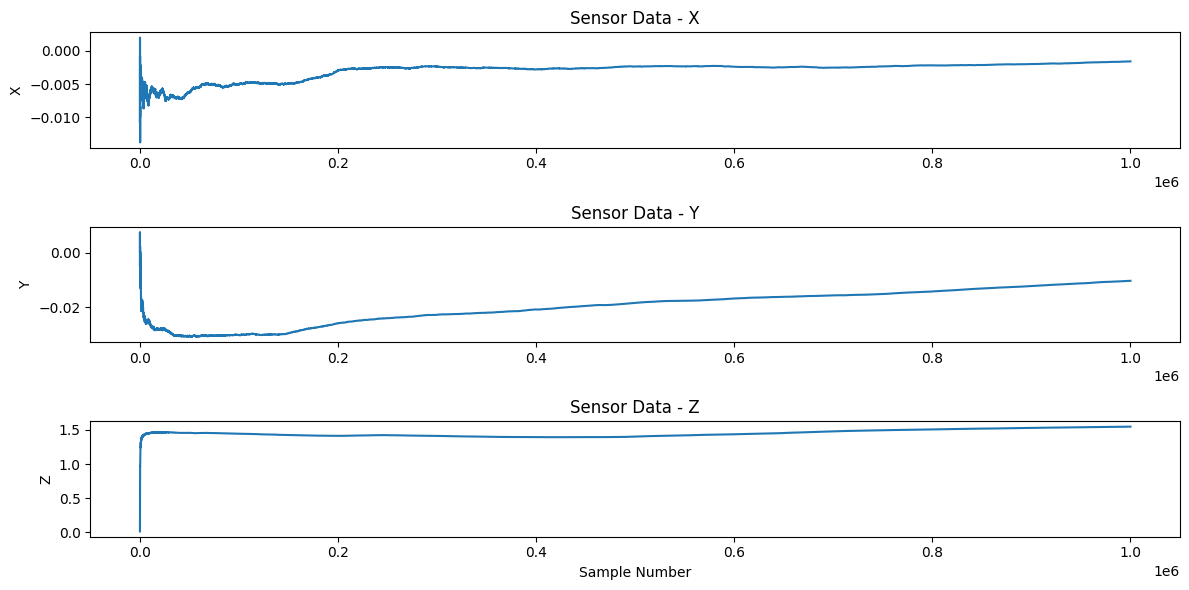

In [102]:
# Supondo que 'df' é seu DataFrame original com as colunas 'X', 'Y', 'Z'
plt.figure(figsize=(12, 6))

# Plotando cada coluna
plt.subplot(3, 1, 1)  # 3 linhas, 1 coluna, posição 1
plt.plot(df['X'], label='X')
plt.title('Sensor Data - X')
plt.ylabel('X')

plt.subplot(3, 1, 2)  # 3 linhas, 1 coluna, posição 2
plt.plot(df['Y'], label='Y')
plt.title('Sensor Data - Y')
plt.ylabel('Y')

plt.subplot(3, 1, 3)  # 3 linhas, 1 coluna, posição 3
plt.plot(df['Z'], label='Z')
plt.title('Sensor Data - Z')
plt.ylabel('Z')
plt.xlabel('Sample Number')

# Mostrando o gráfico
plt.tight_layout()
plt.show()


Normalizando os dados para uso do LSTM

In [103]:
# Definindo o range para -1 a 1, apropriado para sensores com valores entre -180 e 180
scaler = MinMaxScaler(feature_range=(-1, 1))

# Normalizando os dados
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Salvando o scaler ajustado
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Visualizando os primeiros dados normalizados
print(df_scaled.head())

          X         Y         Z
0  0.625715  0.621771 -1.000000
1  0.545189  0.638957 -0.986518
2  0.490763  0.681066 -0.973297
3  0.449535  0.722366 -0.960456
4  0.481299  0.797564 -0.947859


## Dividindo os dados em Treino 70 e Teste 30

In [104]:
# Supondo que 'df' é seu DataFrame com os dados do sensor IMU
total_samples = len(df_scaled)

# Dividindo os dados em 70% para treino e 30% para teste
# train_size = int(total_samples * 0.7)
# test_size = total_samples - train_size

# train_data = df_scaled.iloc[:train_size]
# test_data = df_scaled.iloc[train_size:]

train_data, test_data = train_test_split(df_scaled, test_size=0.3, shuffle=False)

## Configurando valores iniciais
### n_timesteps e n_features

In [105]:
# Convertendo para numpy array
values_train = train_data.values

# Decidindo o número de timesteps e o número de features
n_timesteps = 80  # Exemplo: número de timesteps
n_features = train_data.shape[1]  # Número de features

### Preparando o Treino 30

In [106]:

# Reformatando os dados para a entrada LSTM
X_train, y_train = [], []
for i in range(len(values_train) - n_timesteps):
    X_train.append(values_train[i:(i + n_timesteps), :])
    y_train.append(values_train[i + n_timesteps, :])
X_train, y_train = np.array(X_train), np.array(y_train)

### Preparando o Teste 70

In [107]:
# Supondo que test_data seja seu DataFrame de teste normalizado
# Convertendo para numpy array
values_test = test_data.values

# Reformatando os dados para a entrada LSTM
X_test, y_test = [], []
for i in range(len(values_test) - n_timesteps):
    X_test.append(values_test[i:(i + n_timesteps), :])
    y_test.append(values_test[i + n_timesteps, :])
X_test, y_test = np.array(X_test), np.array(y_test)

# Agora X_test e y_test estão prontos para serem usados para testar o modelo


# Contrução do Modelo LSTM

In [108]:
# Definindo o modelo
model = Sequential()
model.add(LSTM(25, activation='tanh', input_shape=(n_timesteps, n_features)))
# model.add(LSTM(50, activation='relu', input_shape=(n_timesteps, n_features), kernel_regularizer=regularizers.l2(0.01))) # L2: Ruim para dados de sensores, pois induz elementos de aleatoriedade no processo de treinamento
# model.add(Dropout(0.05))  # Dropout de 20% # Dropout: Ruim para dados de sensores, pois induz elementos de aleatoriedade no processo de treinamento
model.add(Dense(n_features))

# Compilando o modelo
# model.compile(optimizer='adam', loss='mse')
# Compilando o modelo com métricas adicionais
model.compile(optimizer='Nadam', loss='mse', metrics=[metrics.MeanSquaredError(), metrics.MeanAbsoluteError(), metrics.RootMeanSquaredError()])


C:\Users\nhf75\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Treinando Modelo com Mean Squared Error (MSE), Mean Absolute Error (MAE), ou até mesmo o Coeficiente de Determinação (R²)

### Training model with Early Stopping

In [109]:
# Treinando o modelo
early_stopping = EarlyStopping(monitor='val_loss', min_delta=0.0000001, patience=10, verbose=1, mode='min')
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=500, 
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

# batch_size=40

Epoch 1/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 161s 114ms/step - loss: 0.0125 - mean_absolute_error: 0.0452 - mean_squared_error: 0.0125 - root_mean_squared_error: 0.0921 - val_loss: 1.9703e-04 - val_mean_absolute_error: 0.0115 - val_mean_squared_error: 1.9703e-04 - val_root_mean_squared_error: 0.0140
Epoch 2/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 156s 111ms/step - loss: 1.8303e-05 - mean_absolute_error: 0.0020 - mean_squared_error: 1.8303e-05 - root_mean_squared_error: 0.0043 - val_loss: 1.1573e-04 - val_mean_absolute_error: 0.0076 - val_mean_squared_error: 1.1573e-04 - val_root_mean_squared_error: 0.0108
Epoch 3/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 162s 115ms/step - loss: 1.4921e-05 - mean_absolute_error: 0.0022 - mean_squared_error: 1.4921e-05 - root_mean_squared_error: 0.0039 - val_loss: 6.1580e-05 - val_mean_absolute_error: 0.0050 - val_mean_squared_error: 6.1580e-05 - val_root_mean_squared_error: 0.0078
Epoch 4/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 131s 93ms/step - loss: 1.3341e-05 - mean_absolut

## Salvar o History

In [110]:
# Salvar o histórico do treinamento em um arquivo JSON
with open("history.json", "w") as f:
    json.dump(history.history, f)

print("Histórico de treinamento salvo em history.json")

Histórico de treinamento salvo em history.json


## Carregando o History do treinamento

In [111]:
# Carregando de JSON
import json
with open('history.json', 'r') as f:
    loaded_history = json.load(f)


#### Salvando o modelo

In [112]:
model.save('Dados Antigos1\model_sensor GY-87_1.keras')  # Salva o modelo no formato HDF5

### Carregando o modelo

In [113]:
modelo_carregado = load_model('model_sensor GY-87_1.keras')
print(modelo_carregado.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 25)             │         2,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            78 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,937 (34.91 KB)

 Trainable params: 2,978 (11.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,959 (23.28 KB)

None


Fazendo previsões

In [114]:
predicted = modelo_carregado.predict(X_test)

9373/9373 ━━━━━━━━━━━━━━━━━━━━ 123s 13ms/step


Plotando os Resultados

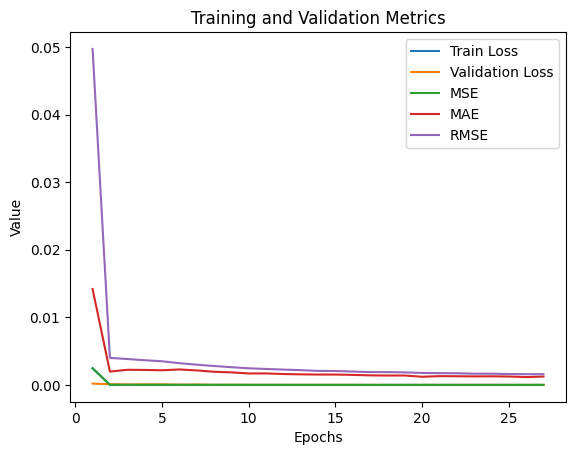

In [115]:
epochs = range(1, len(history.history['loss']) + 1)

plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.plot(epochs, history.history['mean_squared_error'], label='MSE')
plt.plot(epochs, history.history['mean_absolute_error'], label='MAE')
plt.plot(epochs, history.history['root_mean_squared_error'], label='RMSE')
plt.title('Training and Validation Metrics')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()

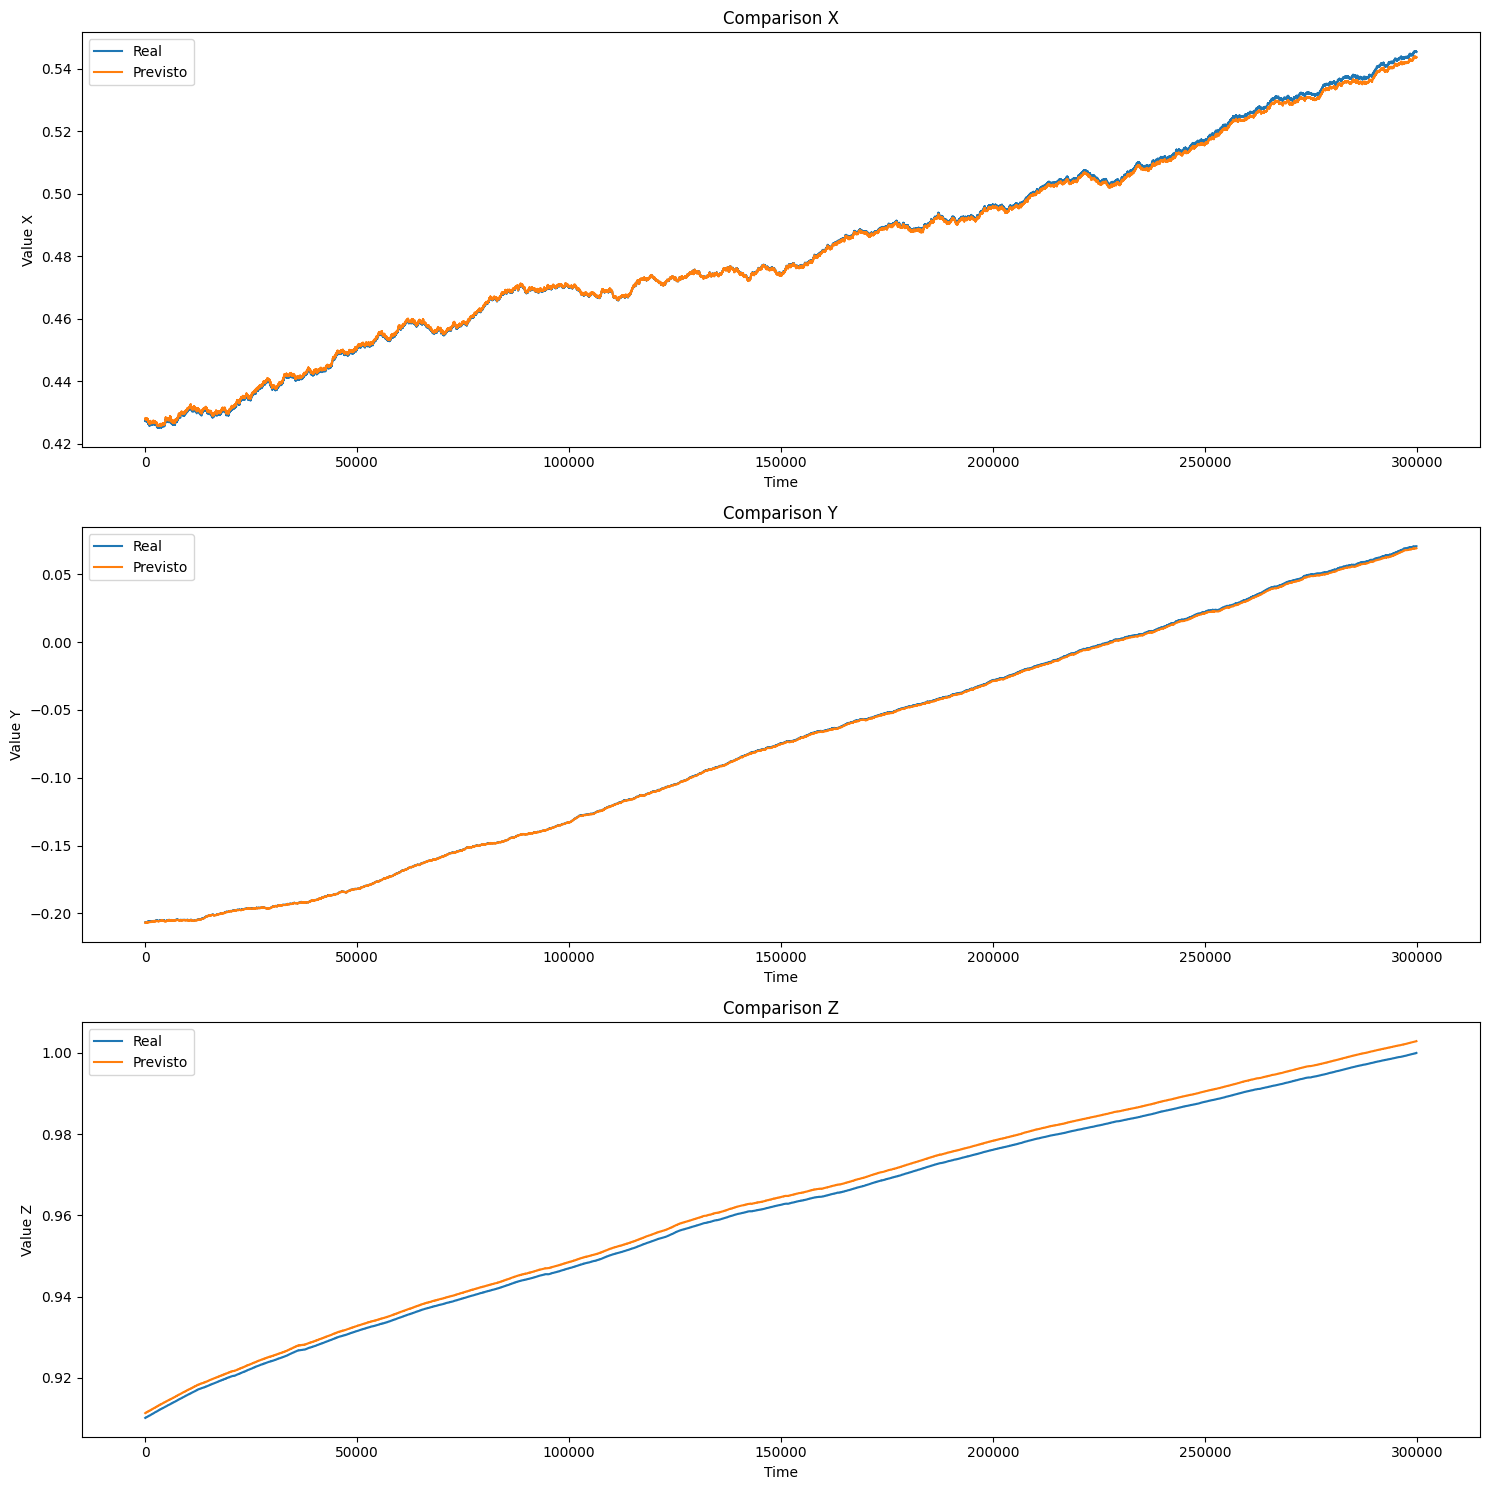

In [116]:
# Definindo as dimensões
dims = ['X', 'Y', 'Z']

plt.figure(figsize=(15, 15))

# Criando um gráfico para cada dimensão
for i, dim in enumerate(dims):
    plt.subplot(3, 1, i+1)
    plt.plot(X_test[:, -1, i], label='Real')
    plt.plot(predicted[:, i], label='Previsto')
    plt.title(f'Comparison {dim}')
    plt.xlabel('Time')
    plt.ylabel(f'Value {dim}')
    plt.legend()

plt.tight_layout()
plt.show()



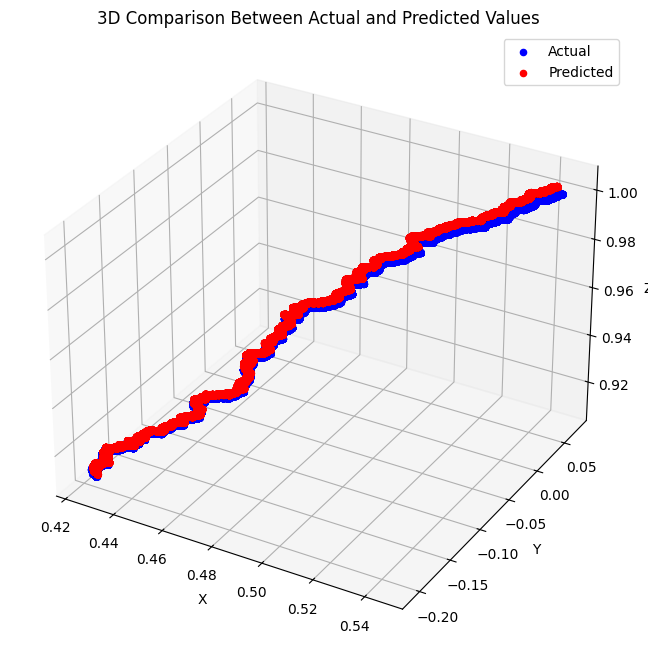

In [117]:

# Criando a figura
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotando os valores reais
ax.scatter(X_test[:, -1, 0], X_test[:, -1, 1], X_test[:, -1, 2], color='blue', label='Actual')

# Plotando os valores previstos
ax.scatter(predicted[:, 0], predicted[:, 1], predicted[:, 2], color='red', label='Predicted')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('3D Comparison Between Actual and Predicted Values')
plt.legend()
plt.show()



## Mean Squared Error e $R^2$

In [118]:
mse = mean_squared_error(y_test, predicted)
r2 = r2_score(y_test, predicted)
print("MSE:", mse)
print("R²:", r2)

MSE: 1.6722539013037956e-06
R²: 0.9976751870912927


## Gráfico $R^2$

In [119]:
print(y_test)

[[ 0.42748137 -0.20660301  0.91010132]
 [ 0.42748436 -0.20660304  0.91010291]
 [ 0.42750179 -0.20660455  0.91010445]
 ...
 [ 0.54531192  0.07078604  0.99999909]
 [ 0.54532147  0.07078574  0.99999956]
 [ 0.54533861  0.07078492  1.        ]]


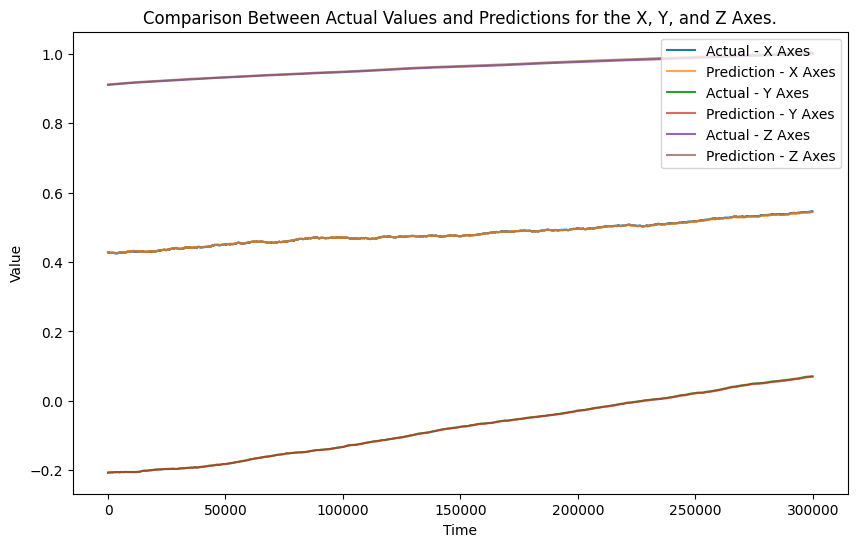

In [120]:
# Separando os eixos dos dados reais
y_test_x = y_test[:, 0]
y_test_y = y_test[:, 1]
y_test_z = y_test[:, 2]

# Separando os eixos das previsões
predicted_x = predicted[:, 0]
predicted_y = predicted[:, 1]
predicted_z = predicted[:, 2]

plt.figure(figsize=(10,6))

# Plot para o eixo X
plt.plot(y_test_x, label='Actual - X Axes')
plt.plot(predicted_x, label='Prediction - X Axes', alpha=0.7)

# Plot para o eixo Y
plt.plot(y_test_y, label='Actual - Y Axes')
plt.plot(predicted_y, label='Prediction - Y Axes', alpha=0.7)

# Plot para o eixo Z
plt.plot(y_test_z, label='Actual - Z Axes')
plt.plot(predicted_z, label='Prediction - Z Axes', alpha=0.7)

plt.title('Comparison Between Actual Values and Predictions for the X, Y, and Z Axes.')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

## Análise

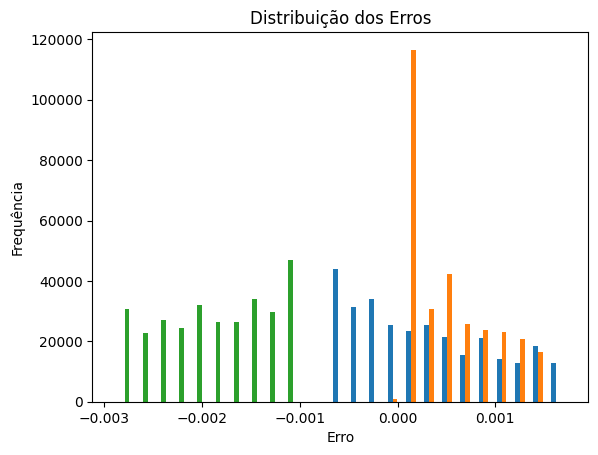

In [121]:
errors = y_test - predicted
plt.hist(errors, bins=25)
plt.title('Distribuição dos Erros')
plt.xlabel('Erro')
plt.ylabel('Frequência')
plt.show()


## Até aqui foi treino e teste em cima de um mesmo conjunto de dados do Sensor 1

# Teste em um novo conjunto de dados do mesmo sensor, o Sensor 1

Carregando Dados Sensor 1

In [122]:
# Carregar os dados do arquivo
file_path1 = 'Dados Antigos1/sensor_data GY-87_1.1.txt'
df1_1 = pd.read_csv(file_path1, header=None, names=['X', 'Y', 'Z'])
print(len(df1_1))
print(df1_1.head())

1000000
          X         Y         Z
0 -0.000077 -0.000776  0.011234
1 -0.000251 -0.001046  0.021659
2 -0.000518 -0.001796  0.031396
3 -0.000203 -0.002821  0.040562
4  0.000105 -0.003350  0.049171


Normalizando os dados

In [123]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
df1_scaled = pd.DataFrame(scaler.fit_transform(df1_1), columns=df1_1.columns)

print(df1_scaled.head())

          X         Y         Z
0  0.067140  1.000000 -1.000000
1  0.050387  0.984434 -0.983351
2  0.024594  0.941209 -0.967800
3  0.054953  0.882199 -0.953162
4  0.084733  0.851742 -0.939412


Preparando os dados de Teste do Sensor 1

In [124]:
# Supondo que test_data seja seu DataFrame de teste normalizado
# Convertendo para numpy array
values_test1 = df1_scaled.values

# Reformatando os dados para a entrada LSTM
X_test1, y_test1 = [], []
for i in range(len(values_test1) - n_timesteps):
    X_test1.append(values_test1[i:(i + n_timesteps), :])
    y_test1.append(values_test1[i + n_timesteps, :])
X_test1, y_test1 = np.array(X_test1), np.array(y_test1)

# Agora X_test e y_test estão prontos para serem usados para testar o modelo

Fazendo a predição

In [125]:
predicted1 = modelo_carregado.predict(X_test1)

31248/31248 ━━━━━━━━━━━━━━━━━━━━ 408s 13ms/step


Plotando os resultados

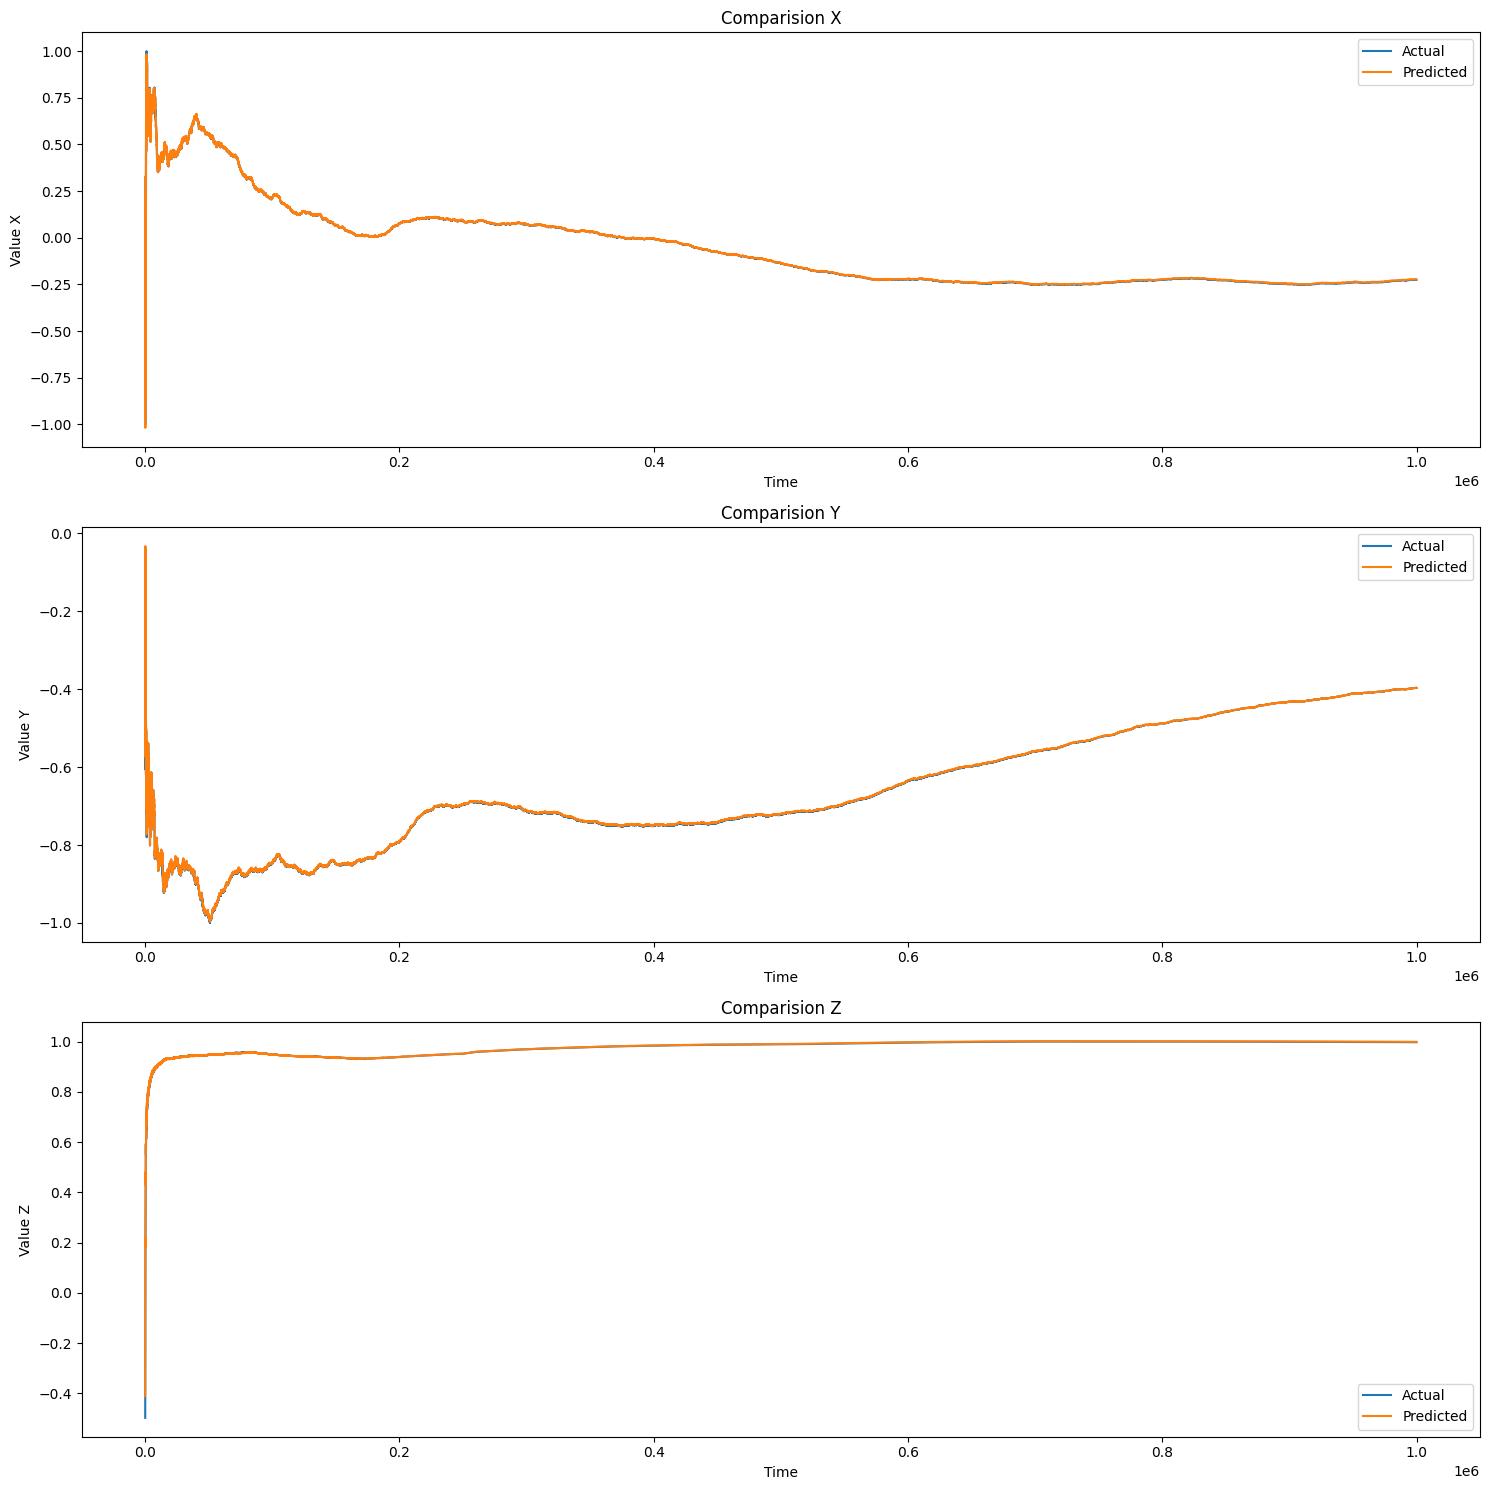

In [126]:
# Definindo as dimensões
dims = ['X', 'Y', 'Z']

plt.figure(figsize=(15, 15))

# Criando um gráfico para cada dimensão
for i, dim in enumerate(dims):
    plt.subplot(3, 1, i+1)
    plt.plot(X_test1[:, -1, i], label='Actual')
    plt.plot(predicted1[:, i], label='Predicted')
    plt.title(f'Comparision {dim}')
    plt.xlabel('Time')
    plt.ylabel(f'Value {dim}')
    plt.legend()

plt.tight_layout()
plt.show()

## Mean Squared Error e $R^2$ nos novos dados do Sensor 1

In [127]:
mse = mean_squared_error(y_test1, predicted1)
r2 = r2_score(y_test1, predicted1)
print("MSE:", mse)
print("R²:", r2)

MSE: 2.6567592764375046e-06
R²: 0.9993151874139845


## Gráfico $R^2$ em Sensor 1

C:\Users\nhf75\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


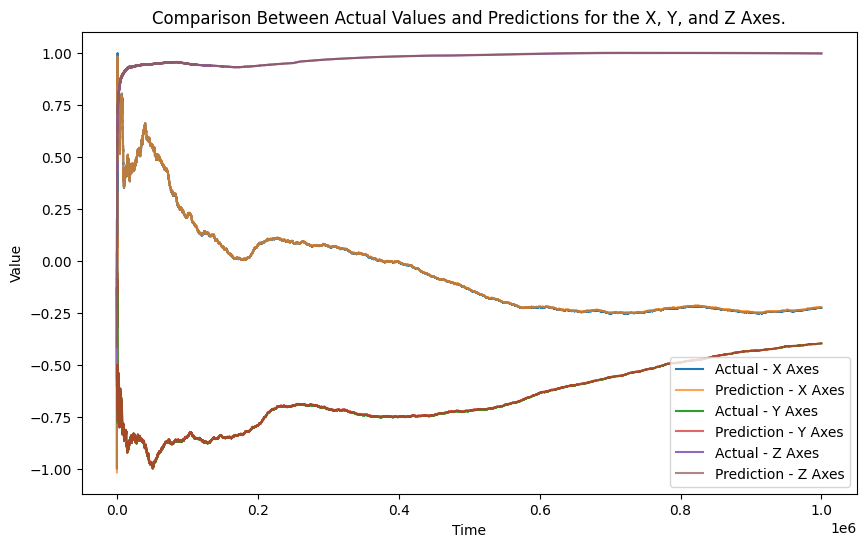

In [128]:
# Separando os eixos dos dados reais
y_test_x = y_test1[:, 0]
y_test_y = y_test1[:, 1]
y_test_z = y_test1[:, 2]

# Separando os eixos das previsões
predicted_x = predicted1[:, 0]
predicted_y = predicted1[:, 1]
predicted_z = predicted1[:, 2]

plt.figure(figsize=(10,6))

# Plot para o eixo X
plt.plot(y_test_x, label='Actual - X Axes')
plt.plot(predicted_x, label='Prediction - X Axes', alpha=0.7)

# Plot para o eixo Y
plt.plot(y_test_y, label='Actual - Y Axes')
plt.plot(predicted_y, label='Prediction - Y Axes', alpha=0.7)

# Plot para o eixo Z
plt.plot(y_test_z, label='Actual - Z Axes')
plt.plot(predicted_z, label='Prediction - Z Axes', alpha=0.7)

plt.title('Comparison Between Actual Values and Predictions for the X, Y, and Z Axes.')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

# Estabilizando o dados estaticos (POC)

Processamento e Inferência com o Modelo Pré-treinado

Aplicação do Modelo em Novos Dados (Inference Pipeline)

Carregamento e Normalização dos Dados de Sensor + Predição

In [129]:
# Suponha que df_novos_dados seja o DataFrame com os novos dados do sensor
# e que o modelo já tenha sido carregado e esteja pronto para uso
# Carregar os novos dados do sensor
file_path = 'Dados Antigos1/sensor_data GY-87_1.1.txt'  # Substitua pelo caminho correto do arquivo
df_novos_dados = pd.read_csv(file_path, header=None, names=['X', 'Y', 'Z'])

# Normalizar os novos dados
df_novos_dados_scaled = pd.DataFrame(scaler.transform(df_novos_dados), columns=df_novos_dados.columns)

# Preparar os dados para o modelo
values_novos_dados = df_novos_dados_scaled.values
X_novos_dados = []
for i in range(len(values_novos_dados) - n_timesteps):
    X_novos_dados.append(values_novos_dados[i:(i + n_timesteps)])
X_novos_dados = np.array(X_novos_dados)

# Fazer previsões com o modelo para cada sequência
predicted_novos_dados = modelo_carregado.predict(X_novos_dados)


31248/31248 ━━━━━━━━━━━━━━━━━━━━ 412s 13ms/step


Pós-processamento das Previsões e Correção dos Dados

Inversão da Normalização, Cálculo de Erro e Correção de Dados

Cálculo e Aplicação do Fator de Correção nos Dados de Sensor

## Fator 70

          X         Y         Z
0  0.004432  0.019127  3.837393
1 -0.034175  0.006677  4.137666
2 -0.020271 -0.000618  4.596552
3  0.010413 -0.019999  4.630677
4  0.010927 -0.005186  4.239083


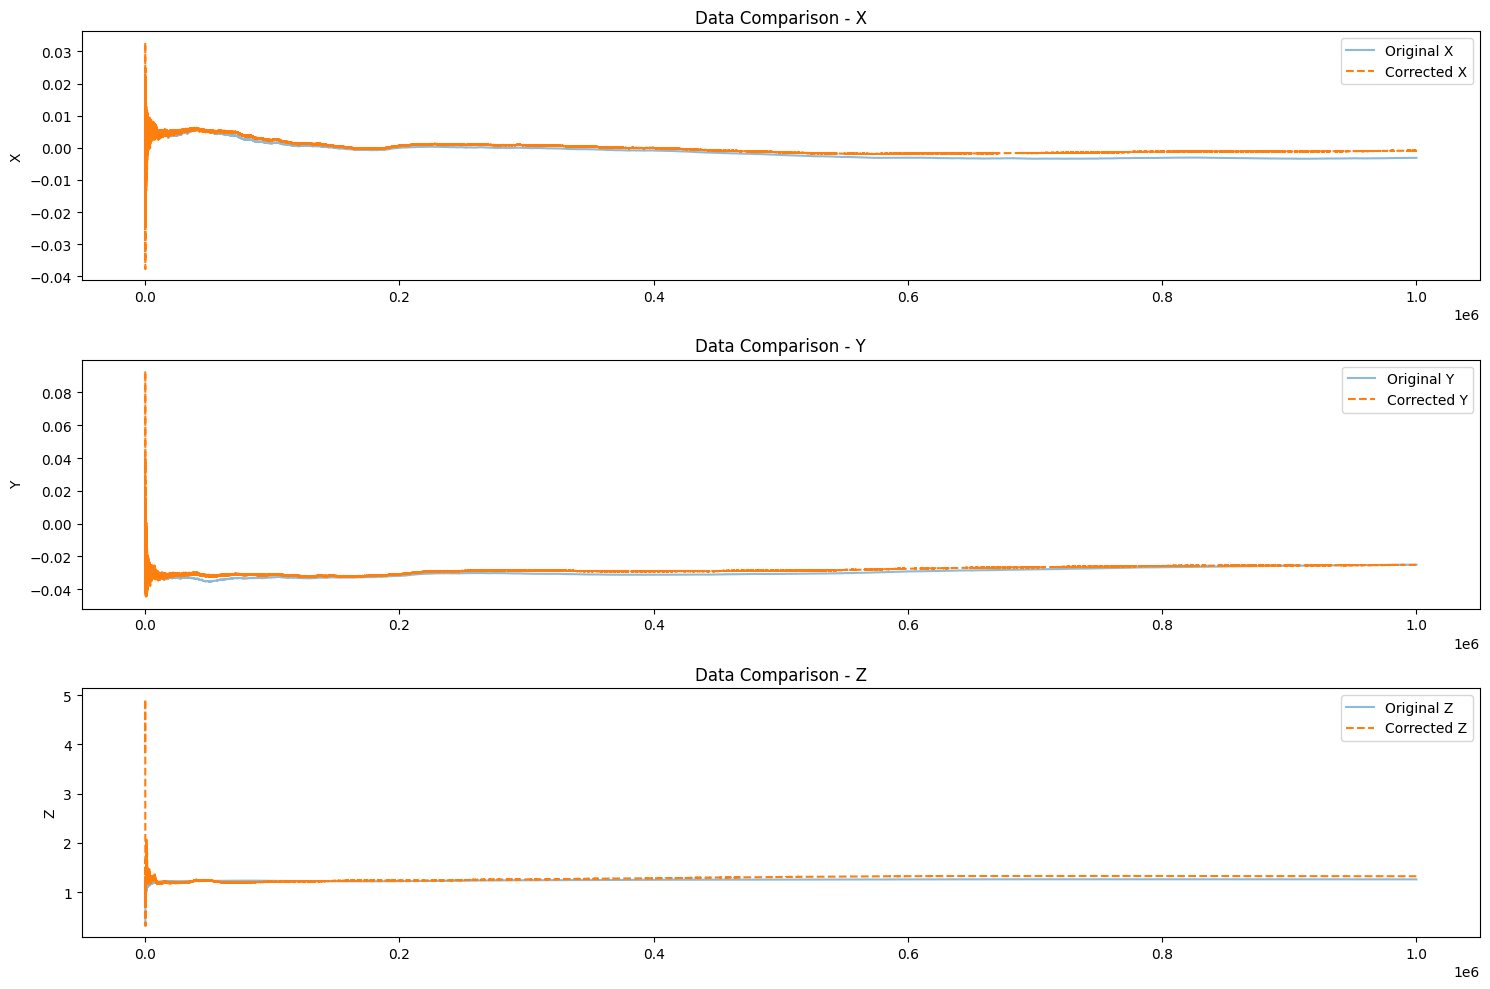

In [130]:
# Inverter a normalização das previsões
predicted_novos_dados_inverse = scaler.inverse_transform(predicted_novos_dados)

## Calcular a diferença entre os dados originais e as previsões
diference = df_novos_dados.values[n_timesteps:] - predicted_novos_dados_inverse
# diference = predicted_novos_dados_inverse

# Fator de correcao
fator_correcao = 70  # Ajuste este valor conforme necessário

# Corrigir os dados originais com base na diferença
dados_corrigidos = df_novos_dados.values[n_timesteps:] - diference * fator_correcao

# Criar um DataFrame com os dados corrigidos
df_corrigido = pd.DataFrame(dados_corrigidos, columns=df_novos_dados.columns)

# Exibir os dados corrigidos
print(df_corrigido.head())

# Plotar os dados originais e corrigidos para comparação
plt.figure(figsize=(15, 10))

# Plot for X
plt.subplot(3, 1, 1)
plt.plot(df_novos_dados['X'][n_timesteps:], label='Original X', alpha=0.5)
plt.plot(df_corrigido['X'], label='Corrected X', linestyle='--')
plt.title('Data Comparison - X')
plt.ylabel('X')
plt.legend()

# Plot for Y
plt.subplot(3, 1, 2)
plt.plot(df_novos_dados['Y'][n_timesteps:], label='Original Y', alpha=0.5)
plt.plot(df_corrigido['Y'], label='Corrected Y', linestyle='--')
plt.title('Data Comparison - Y')
plt.ylabel('Y')
plt.legend()

# Plot for Z
plt.subplot(3, 1, 3)
plt.plot(df_novos_dados['Z'][n_timesteps:], label='Original Z', alpha=0.5)
plt.plot(df_corrigido['Z'], label='Corrected Z', linestyle='--')
plt.title('Data Comparison - Z')
plt.ylabel('Z')
plt.legend()

plt.tight_layout()
plt.show()

## Fator 100

          X         Y         Z
0  0.007660  0.036336  5.340815
1 -0.047576  0.018519  5.768140
2 -0.027725  0.008045  6.422025
3  0.016236 -0.019811  6.469104
4  0.017097  0.001300  5.908008


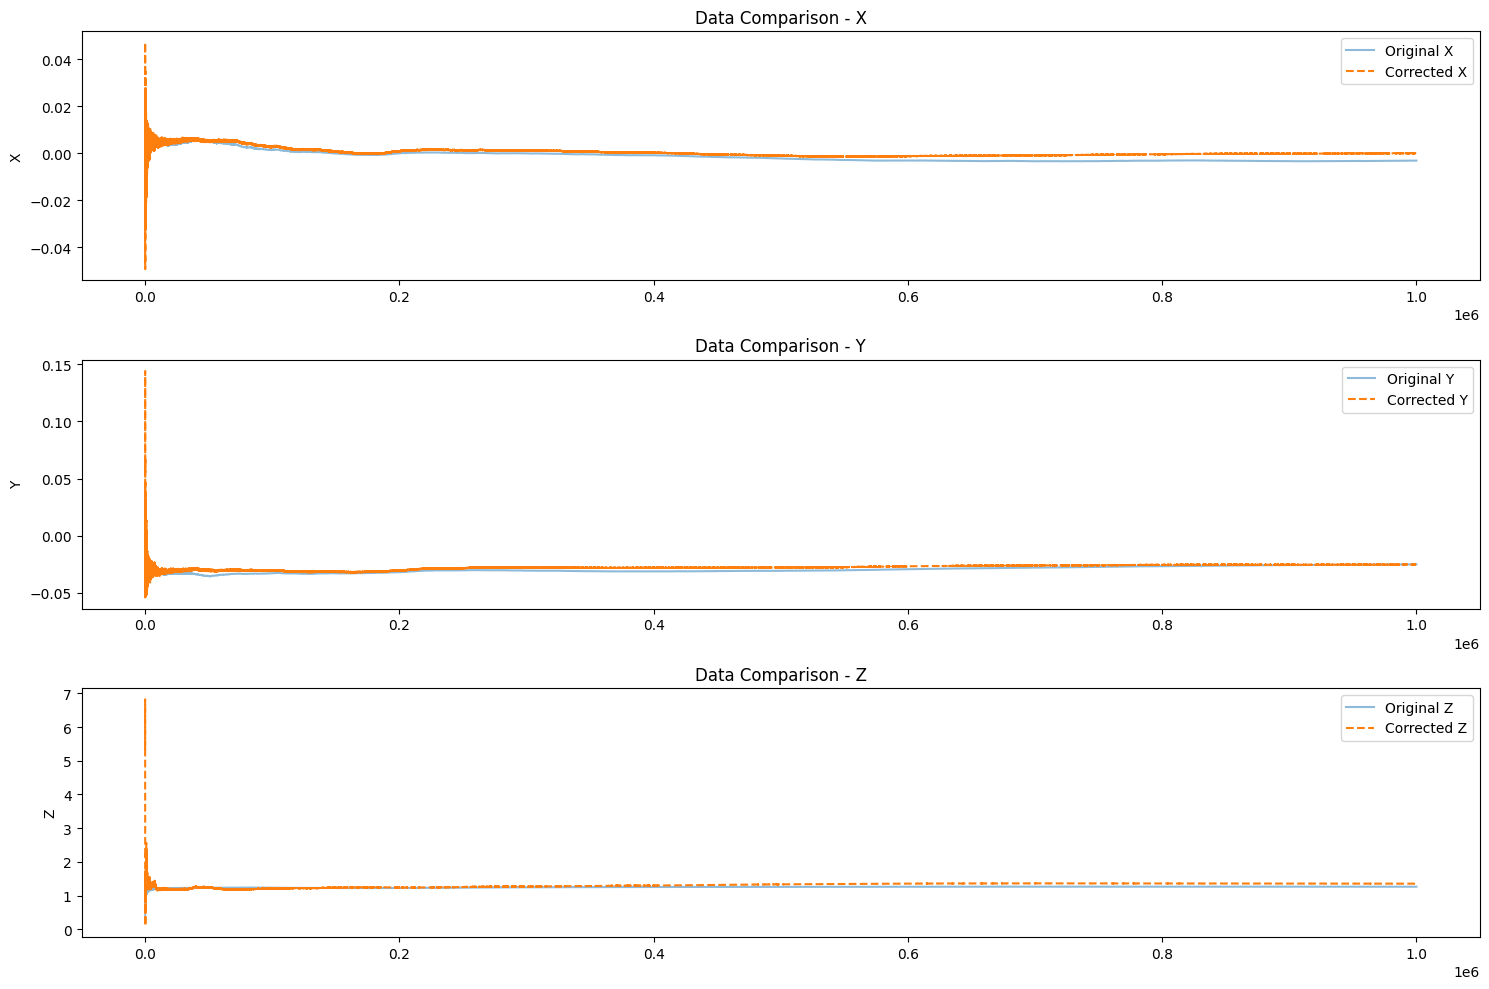

In [131]:
# Inverter a normalização das previsões
# predicted_novos_dados_inverse = scaler.inverse_transform(predicted_novos_dados)

## Calcular a diferença entre os dados originais e as previsões
# diference = df_novos_dados.values[n_timesteps:] - predicted_novos_dados_inverse

# Fator de correcao
fator_correcao = 100  # Ajuste este valor conforme necessário

# Corrigir os dados originais com base na diferença
dados_corrigidos = df_novos_dados.values[n_timesteps:] - diference * fator_correcao

# Criar um DataFrame com os dados corrigidos
df_corrigido = pd.DataFrame(dados_corrigidos, columns=df_novos_dados.columns)

# Exibir os dados corrigidos
print(df_corrigido.head())

# Plotar os dados originais e corrigidos para comparação
plt.figure(figsize=(15, 10))

# Plot for X
plt.subplot(3, 1, 1)
plt.plot(df_novos_dados['X'][n_timesteps:], label='Original X', alpha=0.5)
plt.plot(df_corrigido['X'], label='Corrected X', linestyle='--')
plt.title('Data Comparison - X')
plt.ylabel('X')
plt.legend()

# Plot for Y
plt.subplot(3, 1, 2)
plt.plot(df_novos_dados['Y'][n_timesteps:], label='Original Y', alpha=0.5)
plt.plot(df_corrigido['Y'], label='Corrected Y', linestyle='--')
plt.title('Data Comparison - Y')
plt.ylabel('Y')
plt.legend()

# Plot for Z
plt.subplot(3, 1, 3)
plt.plot(df_novos_dados['Z'][n_timesteps:], label='Original Z', alpha=0.5)
plt.plot(df_corrigido['Z'], label='Corrected Z', linestyle='--')
plt.title('Data Comparison - Z')
plt.ylabel('Z')
plt.legend()

plt.tight_layout()
plt.show()

### Concatenando o gráfico

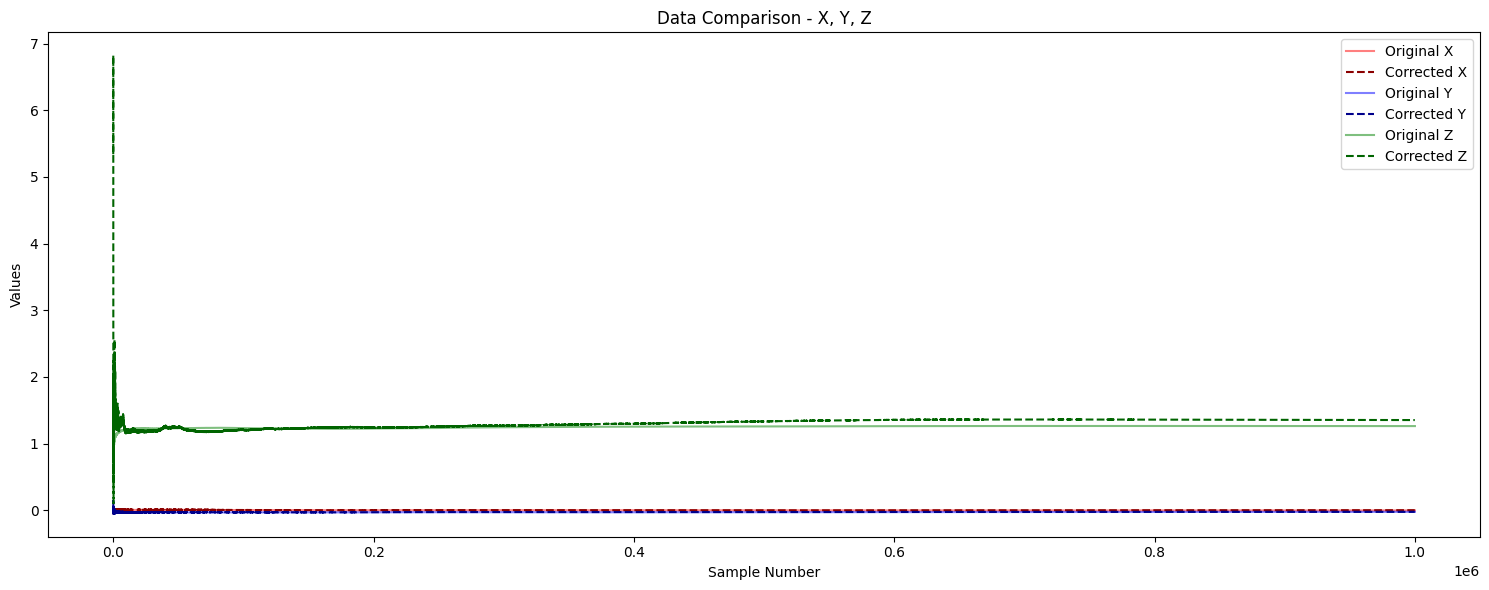

In [132]:
# Plotar os dados originais e corrigidos para comparação em um único gráfico
plt.figure(figsize=(15, 6))

# Plot para X
plt.plot(df_novos_dados['X'][n_timesteps:], label='Original X', alpha=0.5, color='red')
plt.plot(df_corrigido['X'], label='Corrected X', linestyle='--', color='darkred')

# Plot for Y
plt.plot(df_novos_dados['Y'][n_timesteps:], label='Original Y', alpha=0.5, color='blue')
plt.plot(df_corrigido['Y'], label='Corrected Y', linestyle='--', color='darkblue')

# Plot for Z
plt.plot(df_novos_dados['Z'][n_timesteps:], label='Original Z', alpha=0.5, color='green')
plt.plot(df_corrigido['Z'], label='Corrected Z', linestyle='--', color='darkgreen')

plt.title('Data Comparison - X, Y, Z')
plt.ylabel('Values')
plt.xlabel('Sample Number')
plt.legend()

plt.tight_layout()
plt.show()


Exibir um trecho dos dados em forma de tabela “amigável”

In [133]:
# Comparar original (cortado em n_timesteps) e corrigido
df_comparacao = pd.DataFrame({
    'Original_X': df_novos_dados['X'][n_timesteps:].values*17.77777777,
    'Corrigido_X': df_corrigido['X'].values*17.77777777,
    # 'Original_Y': df_novos_dados['Y'][n_timesteps:].values,
    # 'Corrigido_Y': df_corrigido['Y'].values,
    'Original_Z': df_novos_dados['Z'][n_timesteps:].values*17.77777777,
    'Corrigido_Z': df_corrigido['Z'].values*17.77777777
})

# Exibir apenas as 10 primeiras linhas (exemplo) EM MILÉSIMOS
print(df_comparacao.head(10))


   Original_X  Corrigido_X  Original_Z  Corrigido_Z
0   -0.055100     0.136182    5.856118    94.947824
1   -0.051651    -0.845804    5.924024   102.544706
2   -0.051154    -0.492897    5.993132   114.169341
3   -0.056460     0.288648    6.062454   115.006288
4   -0.061708     0.303952    6.131988   105.031258
5   -0.064988    -0.015906    6.200774    97.827768
6   -0.065381    -0.339717    6.269775    96.610240
7   -0.063879    -0.411396    6.338988   100.659785
8   -0.060511    -0.447543    6.412172   103.888772
9   -0.059050    -0.171527    6.489263   105.208537


## Mostrar métricas de erro (RMSE, MAE, etc.)

In [134]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Interferência predita (erro que foi removido)
interferencia_predita =  df_corrigido.values

# Calcular métricas para X
mse_x = mean_squared_error(df_novos_dados['X'][n_timesteps:], interferencia_predita[:, 0])
rmse_x = np.sqrt(mse_x)
mae_x = mean_absolute_error(df_novos_dados['X'][n_timesteps:], interferencia_predita[:, 0])
r2_x  = r2_score(df_novos_dados['X'][n_timesteps:], interferencia_predita[:, 0])

# Calcular métricas para Y
mse_y = mean_squared_error(df_novos_dados['Y'][n_timesteps:], interferencia_predita[:, 1])
rmse_y = np.sqrt(mse_y)
mae_y = mean_absolute_error(df_novos_dados['Y'][n_timesteps:], interferencia_predita[:, 1])
r2_y  = r2_score(df_novos_dados['Y'][n_timesteps:], interferencia_predita[:, 1])

# Calcular métricas para Z
mse_z = mean_squared_error(df_novos_dados['Z'][n_timesteps:], interferencia_predita[:, 2])
rmse_z = np.sqrt(mse_z)
mae_z = mean_absolute_error(df_novos_dados['Z'][n_timesteps:], interferencia_predita[:, 2])
r2_z  = r2_score(df_novos_dados['Z'][n_timesteps:], interferencia_predita[:, 2])

# Exibir as métricas em um DataFrame
df_metricas_interferencia = pd.DataFrame({
    'Eixo': ['X', 'Y', 'Z'],
    'MSE':  [mse_x, mse_y, mse_z],
    'RMSE': [rmse_x, rmse_y, rmse_z],
    'MAE':  [mae_x, mae_y, mae_z],
    'R²':   [r2_x, r2_y, r2_z]
})

print("\nMétricas de Detecção da Interferência:")
print(df_metricas_interferencia)



Métricas de Detecção da Interferência:
  Eixo       MSE      RMSE       MAE         R²
0    X  0.000004  0.002064  0.001810   0.189315
1    Y  0.000006  0.002481  0.002007   0.090433
2    Z  0.007693  0.087709  0.064910 -17.823407


## Teste em um conjunto de dados do Sensor 2

Carregando Dados Sensor 2

In [135]:
# Carregar os dados do arquivo
file_path2 = 'Dados Antigos1/sensor_data GY-87_2.txt'
df2 = pd.read_csv(file_path2, header=None, names=['X', 'Y', 'Z'])
print(len(df2))
print(df2.head())

1000000
          X         Y         Z
0  0.000111 -0.000114  0.013160
1  0.000024  0.000363  0.025670
2  0.000424  0.000830  0.037549
3  0.001105  0.000712  0.049007
4  0.001868  0.000215  0.059960


Normalizando os dados

In [136]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
df2_scaled = pd.DataFrame(scaler.fit_transform(df2), columns=df2.columns)

print(df2_scaled.head())

          X         Y         Z
0 -0.336652  0.641444 -1.000000
1 -0.347273  0.664355 -0.977846
2 -0.298474  0.686821 -0.956810
3 -0.215427  0.681127 -0.936520
4 -0.122345  0.657233 -0.917121


Preparando os dados de Teste do Sensor 2

In [137]:
# Supondo que test_data seja seu DataFrame de teste normalizado
# Convertendo para numpy array
values_test2 = df2_scaled.values

# Reformatando os dados para a entrada LSTM
X_test2, y_test2 = [], []
for i in range(len(values_test2) - n_timesteps):
    X_test2.append(values_test2[i:(i + n_timesteps), :])
    y_test2.append(values_test2[i + n_timesteps, :])
X_test2, y_test2 = np.array(X_test2), np.array(y_test2)

# Agora X_test e y_test estão prontos para serem usados para testar o modelo

Fazendo a predição

In [138]:
predicted2 = modelo_carregado.predict(X_test2)

31248/31248 ━━━━━━━━━━━━━━━━━━━━ 400s 13ms/step


Plotando os resultados

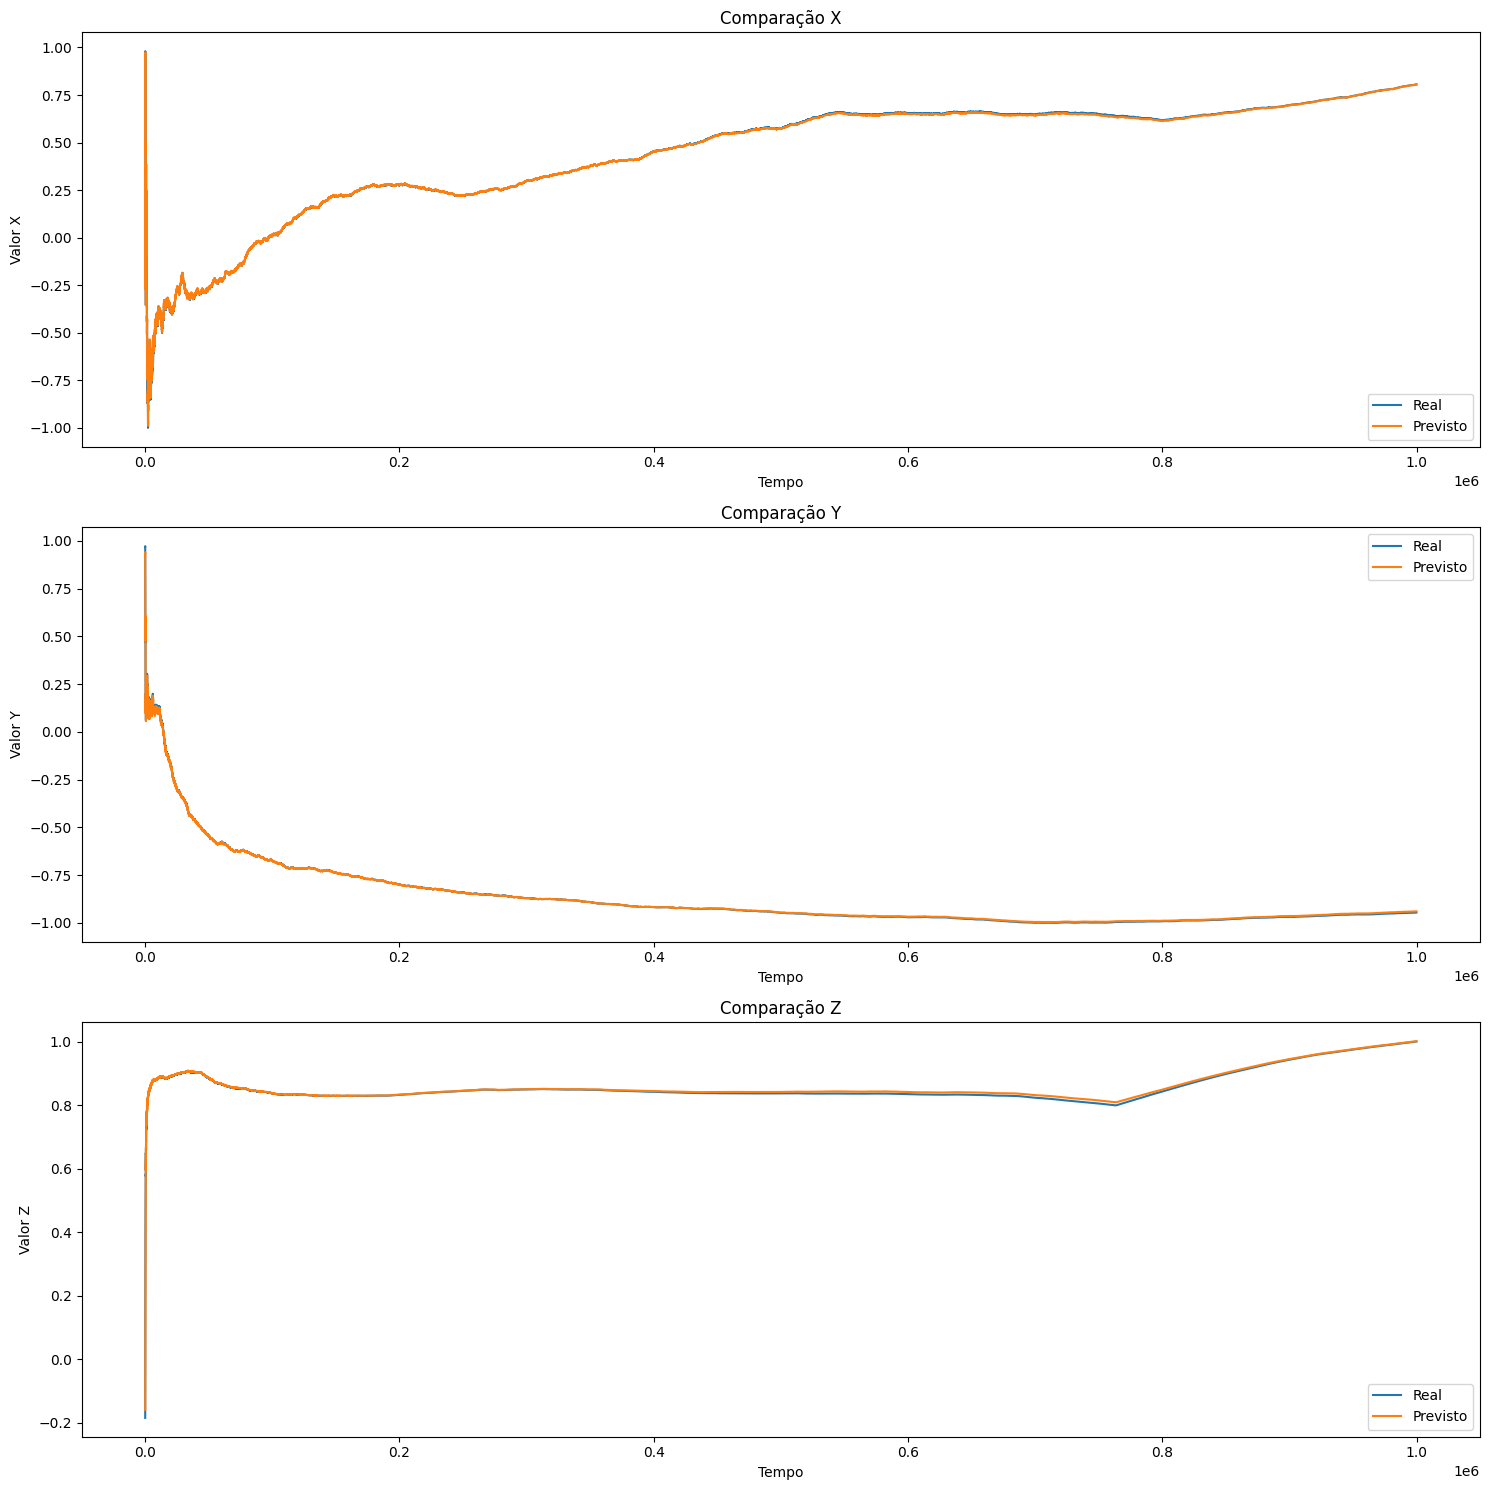

In [139]:
# Definindo as dimensões
dims = ['X', 'Y', 'Z']

plt.figure(figsize=(15, 15))

# Criando um gráfico para cada dimensão
for i, dim in enumerate(dims):
    plt.subplot(3, 1, i+1)
    plt.plot(X_test2[:, -1, i], label='Real')
    plt.plot(predicted2[:, i], label='Previsto')
    plt.title(f'Comparação {dim}')
    plt.xlabel('Tempo')
    plt.ylabel(f'Valor {dim}')
    plt.legend()

plt.tight_layout()
plt.show()

## Mean Squared Error e $R^2$ no Sensor 2

In [140]:
mse = mean_squared_error(y_test2, predicted2)
r2 = r2_score(y_test2, predicted2)
print("MSE:", mse)
print("R²:", r2)

MSE: 1.3092884963405632e-05
R²: 0.9968757348024303


## Gráfico $R^2$ em Sensor 2

C:\Users\nhf75\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


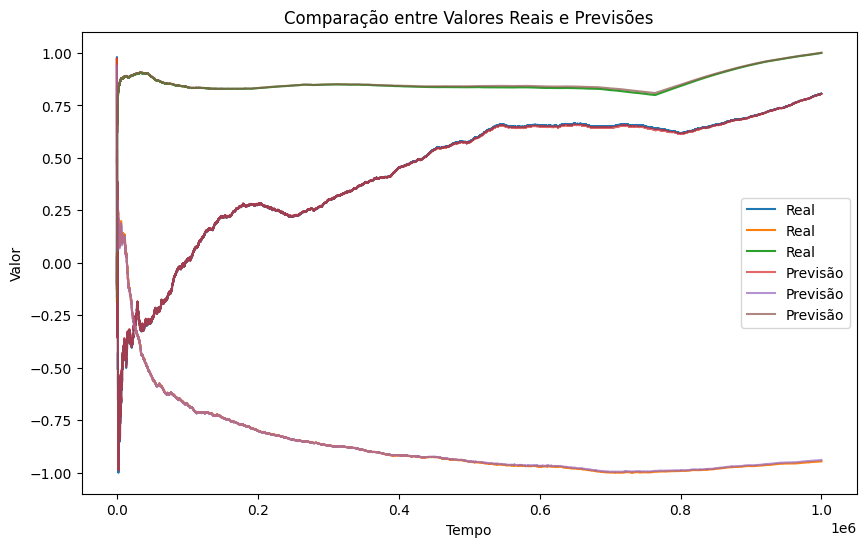

In [141]:
plt.figure(figsize=(10,6))
plt.plot(y_test2, label='Real')
plt.plot(predicted2, label='Previsão', alpha=0.7)
plt.title('Comparação entre Valores Reais e Previsões')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.show()

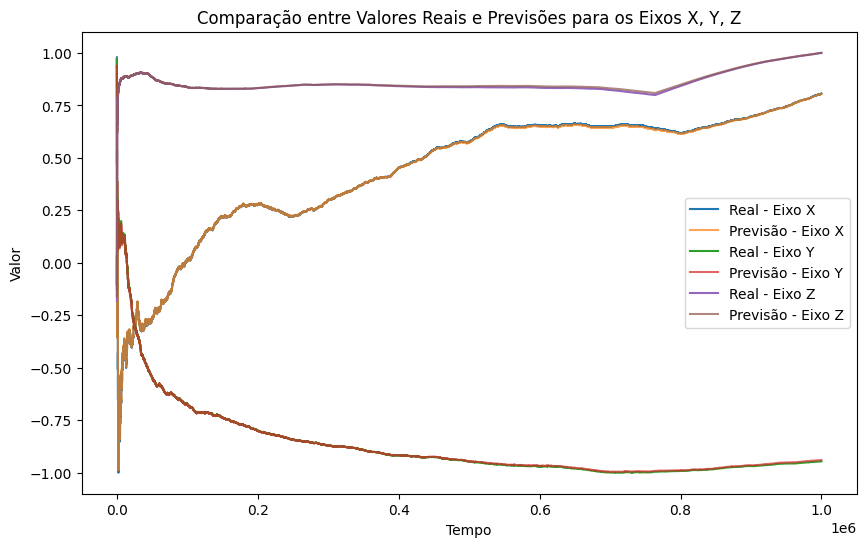

In [142]:
# Separando os eixos dos dados reais
y_test_x = y_test2[:, 0]
y_test_y = y_test2[:, 1]
y_test_z = y_test2[:, 2]

# Separando os eixos das previsões
predicted_x = predicted2[:, 0]
predicted_y = predicted2[:, 1]
predicted_z = predicted2[:, 2]

plt.figure(figsize=(10,6))

# Plot para o eixo X
plt.plot(y_test_x, label='Real - Eixo X')
plt.plot(predicted_x, label='Previsão - Eixo X', alpha=0.7)

# Plot para o eixo Y
plt.plot(y_test_y, label='Real - Eixo Y')
plt.plot(predicted_y, label='Previsão - Eixo Y', alpha=0.7)

# Plot para o eixo Z
plt.plot(y_test_z, label='Real - Eixo Z')
plt.plot(predicted_z, label='Previsão - Eixo Z', alpha=0.7)

plt.title('Comparação entre Valores Reais e Previsões para os Eixos X, Y, Z')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.show()

## Teste em um conjunto de dados do Sensor 3

Carregando Dados Sensor 2

In [143]:
# Carregar os dados do arquivo
file_path3 = 'Dados Antigos1/sensor_data GY-87_3.txt'
df3 = pd.read_csv(file_path3, header=None, names=['X', 'Y', 'Z'])
print(len(df3))
print(df3.head())

1000000
          X         Y         Z
0 -0.000159  0.001249  0.016058
1 -0.000315  0.002180  0.031802
2 -0.000079  0.002704  0.047337
3  0.000248  0.003411  0.062573
4  0.000188  0.004294  0.077519


Normalizando os dados

In [144]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
df3_scaled = pd.DataFrame(scaler.fit_transform(df3), columns=df3.columns)

print(df3_scaled.head())

          X         Y         Z
0  0.911740  0.750230 -1.000000
1  0.910683  0.763893 -0.972079
2  0.912280  0.771590 -0.944527
3  0.914498  0.781961 -0.917505
4  0.914090  0.794932 -0.890998


Preparando os dados de Teste do Sensor 3

In [145]:
# Supondo que test_data seja seu DataFrame de teste normalizado
# Convertendo para numpy array
values_test3 = df3_scaled.values

# Reformatando os dados para a entrada LSTM
X_test3, y_test3 = [], []
for i in range(len(values_test3) - n_timesteps):
    X_test3.append(values_test3[i:(i + n_timesteps), :])
    y_test3.append(values_test3[i + n_timesteps, :])
X_test3, y_test3 = np.array(X_test3), np.array(y_test3)

# Agora X_test e y_test estão prontos para serem usados para testar o modelo

Fazendo a predição

In [146]:
predicted3 = modelo_carregado.predict(X_test3)

31248/31248 ━━━━━━━━━━━━━━━━━━━━ 389s 12ms/step


Plotando os resultados

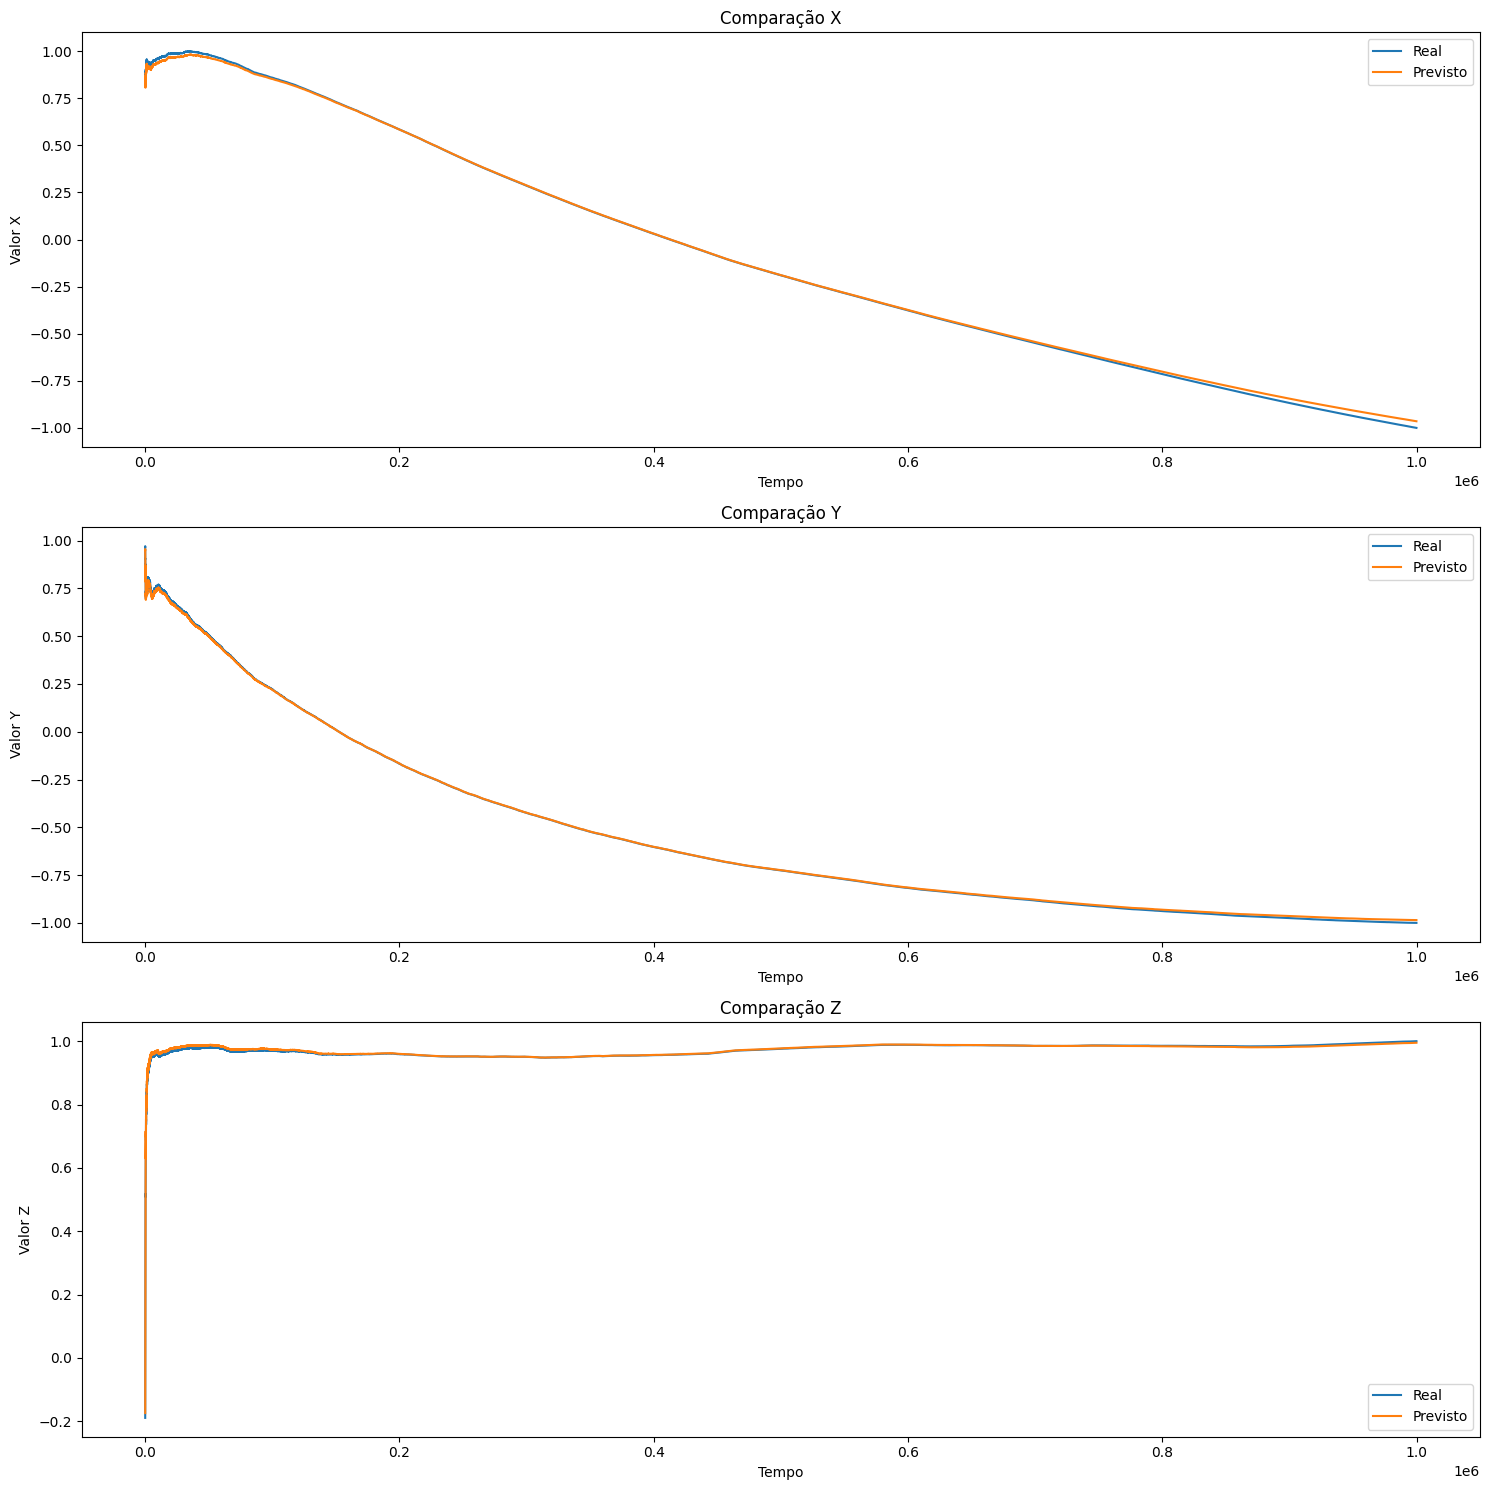

In [147]:
# Definindo as dimensões
dims = ['X', 'Y', 'Z']

plt.figure(figsize=(15, 15))

# Criando um gráfico para cada dimensão
for i, dim in enumerate(dims):
    plt.subplot(3, 1, i+1)
    plt.plot(X_test3[:, -1, i], label='Real')
    plt.plot(predicted3[:, i], label='Previsto')
    plt.title(f'Comparação {dim}')
    plt.xlabel('Tempo')
    plt.ylabel(f'Valor {dim}')
    plt.legend()

plt.tight_layout()
plt.show()

## Mean Squared Error e $R^2$ no Sensor 3

In [148]:
mse = mean_squared_error(y_test3, predicted3)
r2 = r2_score(y_test3, predicted3)
print("MSE:", mse)
print("R²:", r2)

MSE: 6.690869460282342e-05
R²: 0.9930009784195767


## Gráfico $R^2$ em Sensor 3

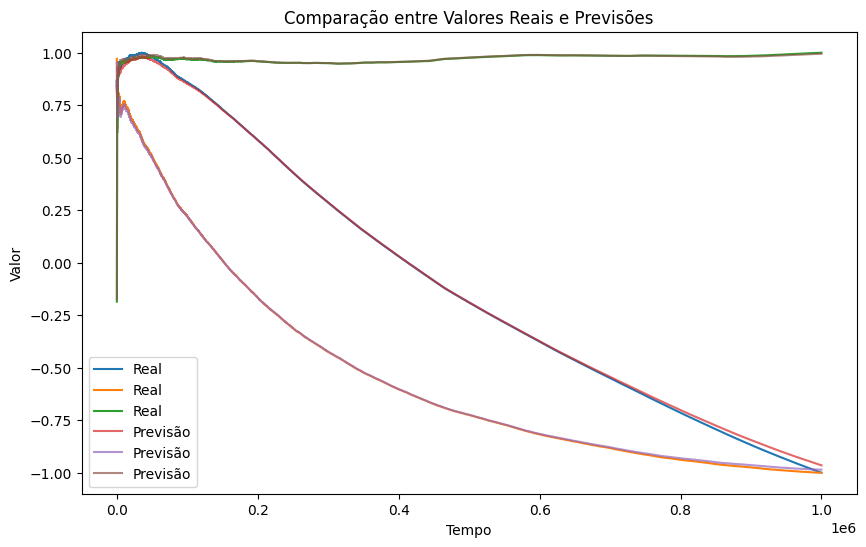

In [149]:
plt.figure(figsize=(10,6))
plt.plot(y_test3, label='Real')
plt.plot(predicted3, label='Previsão', alpha=0.7)
plt.title('Comparação entre Valores Reais e Previsões')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.show()

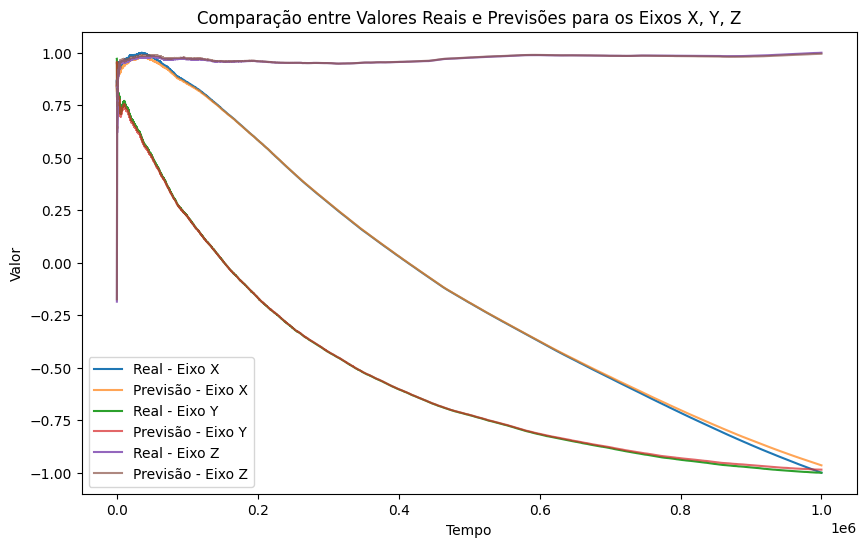

In [150]:
# Separando os eixos dos dados reais
y_test_x = y_test3[:, 0]
y_test_y = y_test3[:, 1]
y_test_z = y_test3[:, 2]

# Separando os eixos das previsões
predicted_x = predicted3[:, 0]
predicted_y = predicted3[:, 1]
predicted_z = predicted3[:, 2]

plt.figure(figsize=(10,6))

# Plot para o eixo X
plt.plot(y_test_x, label='Real - Eixo X')
plt.plot(predicted_x, label='Previsão - Eixo X', alpha=0.7)

# Plot para o eixo Y
plt.plot(y_test_y, label='Real - Eixo Y')
plt.plot(predicted_y, label='Previsão - Eixo Y', alpha=0.7)

# Plot para o eixo Z
plt.plot(y_test_z, label='Real - Eixo Z')
plt.plot(predicted_z, label='Previsão - Eixo Z', alpha=0.7)

plt.title('Comparação entre Valores Reais e Previsões para os Eixos X, Y, Z')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.show()